# 1. Limpieza de Datos

In [14]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('./data/titanic.csv')

In [10]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.900,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.750,NaN,Q
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.275,NaN,S


In [11]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
print("Valores nulos por columna")
print(df.isnull().sum())

Valores nulos por columna
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


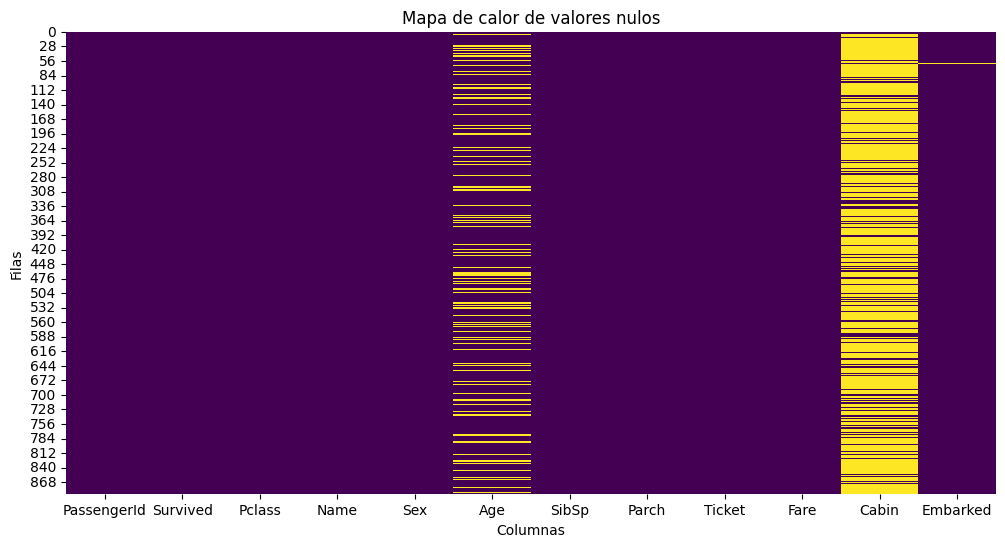

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(12, 6))
# Mapa de calor de valores nulos
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

# Títulos y etiquetas
plt.title("Mapa de calor de valores nulos")
plt.xlabel("Columnas")
plt.ylabel("Filas")

# Mostrar gráfico
plt.show()

In [16]:
# Calcular porcentaje de valores faltantes por columna
missing_percentage = (
    df.isnull().mean() * 100
).round(2).sort_values(ascending=False)

# Mostrar resultados
print(missing_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


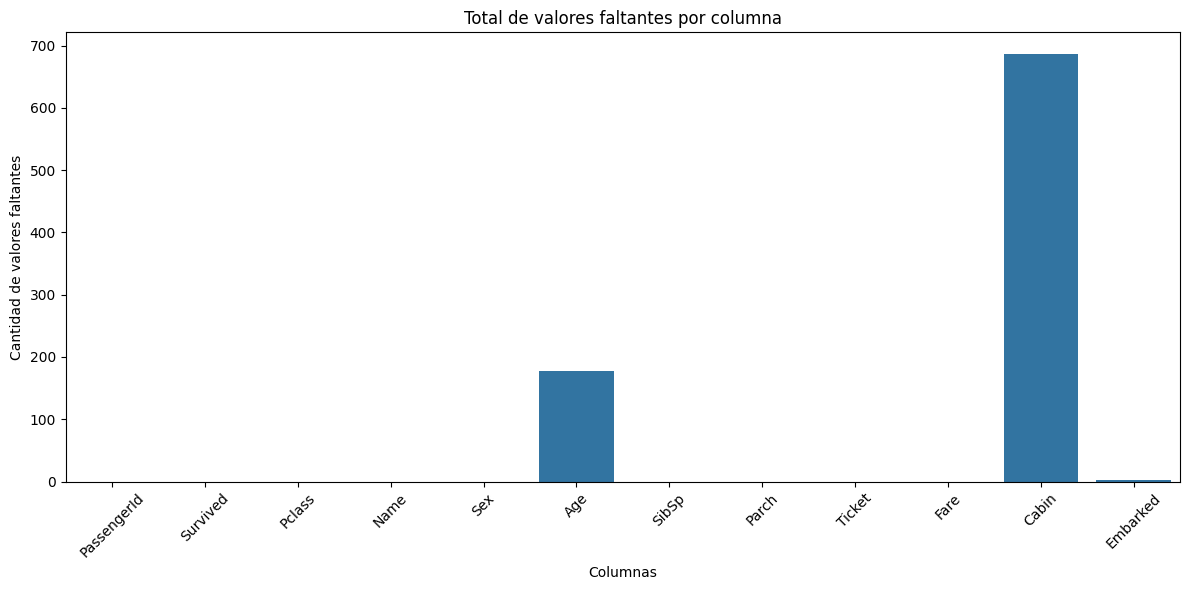

In [17]:
# Calcular total de valores faltantes por columna
missing_values = df.isnull().sum()

# Crear figura
plt.figure(figsize=(12, 6))

# Gráfica de barras
sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

# Rotar nombres de columnas
plt.xticks(rotation=45)

# Títulos y etiquetas
plt.title("Total de valores faltantes por columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de valores faltantes")

# Ajustar diseño
plt.tight_layout()

# Mostrar gráfica
plt.show()

In [18]:
# Eliminar la columna 'Cabin' debido a su alto porcentaje de valores faltantes
df.drop('Cabin', axis = 1, inplace = True)

In [25]:
# Calcular la mediana de la columna Age
median_age = df['Age'].median()

# Imputar los valores nulos con la mediana
df['Age'] = df['Age'].fillna(median_age)

In [20]:
# Rellenar valores nulos de Embarked con la moda
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [26]:
round(df.isnull().sum().sort_values(ascending = False) / len(df) * 100, 2)

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [30]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [28]:
# Verificar si hay filas duplicadas
df.duplicated().sum()

np.int64(0)

In [29]:
df.drop('Name', axis = 1, inplace = True)
df.drop('Ticket', axis = 1, inplace = True)
df.drop('PassengerId', axis = 1, inplace = True)

In [31]:
print(f"Después de limpiar df: {df.shape[0]} filas y {df.shape[1]} columnas.")

Después de limpiar df: 891 filas y 8 columnas.


In [32]:
df.to_csv('./data/titanic_clean.csv', index=False)